# Rossman Store Sales: EDA

In this notebook, we try explore the Rossmann data and try to find some insights
before jumping into processing the data.

The found **insights** are listed at the end of the notebook.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

# Add the parent directory (project root) to sys.path if not already there
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [3]:
import random
import warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.core.display_functions import display

warnings.filterwarnings("ignore")

## Load datasets

In [4]:
DATA_PATH = "../data/"

train = pd.read_csv(f"{DATA_PATH}/train.csv", parse_dates=["Date"])
test = pd.read_csv(f"{DATA_PATH}/test.csv", parse_dates=["Date"])
store = pd.read_csv(f"{DATA_PATH}/store.csv")

train = train.merge(store, on="Store")
test = test.merge(store, on="Store")

print("Train dataset:")
display(train.head())
display(f"Train size: {train.shape}")

print("Test dataset:")
display(test.head())
display(f"Test size: {test.shape}")

Train dataset:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


'Train size: (1017209, 18)'

Test dataset:


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN


'Test size: (41088, 17)'

## Preprocessing

For some checks, we might have to preprocess the data.

In [56]:
train["year"] = train["Date"].dt.year
train["month"] = train["Date"].dt.month

## Exploration

Before building any Machine Learning model, we have to explore the data
so that we can better understand it.

In [5]:
# How many stores and number of records?
num_stores = train.groupby("Store")["Sales"].count().to_frame("num_records")
num_stores.describe()

,num_records
count,1115.000000
mean,912.295067
std,67.729422
min,758.000000
25%,942.000000
50%,942.000000
75%,942.000000
max,942.000000


In [6]:
# What's the Sales look like when the Stores are open?
open_sales = train[train["Open"] == 1]

open_sales[["Sales"]].describe().round(2)

,Sales
count,844392.00
mean,6955.51
std,3104.21
min,0.00
25%,4859.00
50%,6369.00
75%,8360.00
max,41551.00


In [7]:
# What's the Sales look like when the Stores are open?
open_sales_desc = open_sales.groupby("Store")["Sales"].describe()
open_sales_desc.round(2).sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Store,,,,,,,,
817,784.0,21757.48,4674.80,6052.0,19154.75,21872.0,24663.25,38025.0
262,942.0,20718.52,4668.88,13210.0,17454.25,19415.5,22125.00,38722.0
1114,784.0,20666.56,3452.94,8880.0,18366.50,20412.5,22350.00,35697.0
251,779.0,19123.07,3547.64,8373.0,16536.50,18566.0,21033.00,35350.0
842,622.0,18574.80,3788.99,7769.0,15908.00,18330.0,20665.25,35154.0
...,...,...,...,...,...,...,...,...
841,780.0,2972.61,1096.26,958.0,2302.25,2907.0,3625.75,7020.0
208,784.0,2936.29,716.53,1546.0,2405.75,2927.5,3358.75,5864.0
198,782.0,2900.60,1597.76,530.0,1769.75,2526.0,3756.75,10676.0


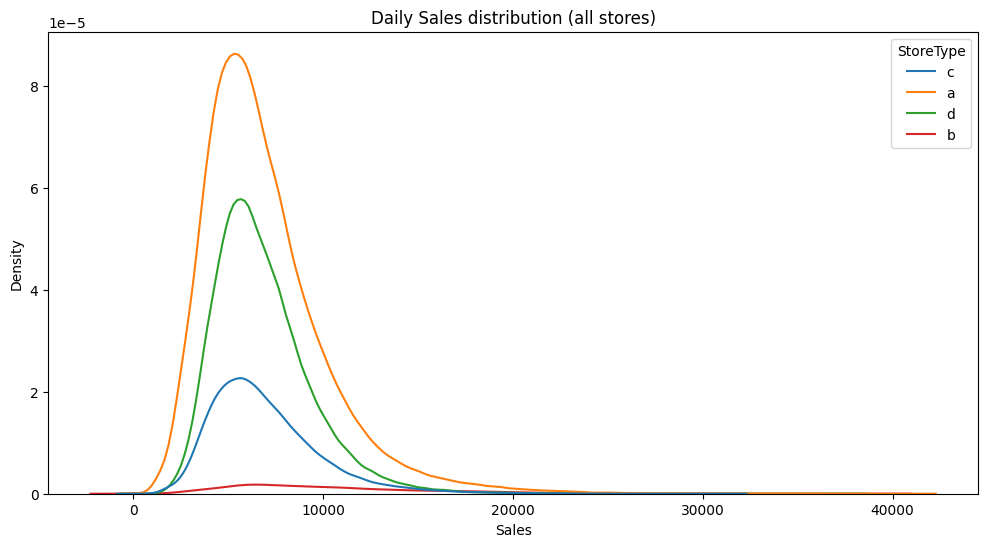

In [8]:
fig, ax = plt.subplots(figsize=(12,6))
sns.kdeplot(data=open_sales, x="Sales", hue="StoreType")
ax.set(title="Daily Sales distribution (all stores)");

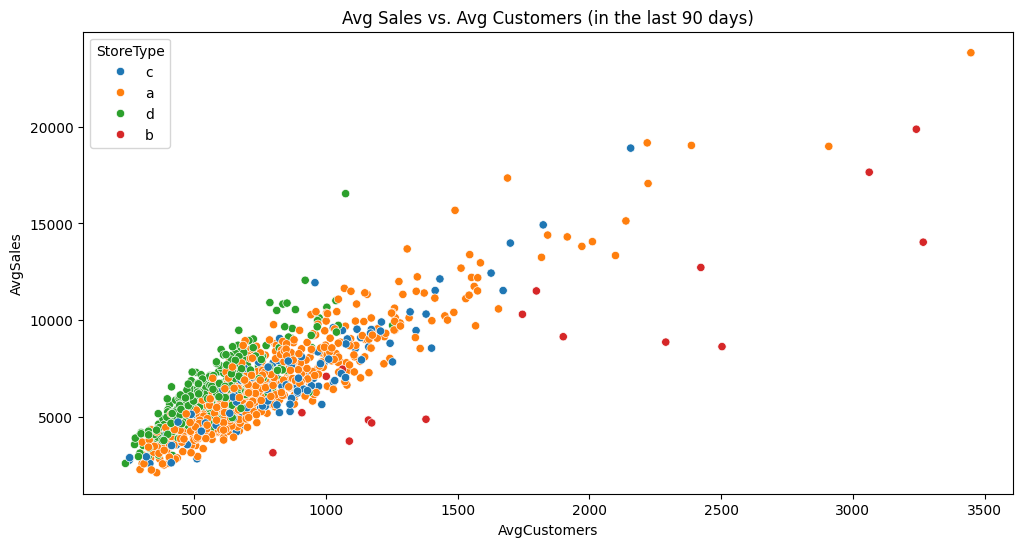

In [18]:
# Checking the avg. sales vs avg. customer (in the last 90 days)
last90days_sales = open_sales.groupby("Store").tail(90).sort_values(
    ["Store", "Date"])

sales_last90d = last90days_sales.groupby("Store").agg({
    "Sales": "mean",
    "Customers": "mean",
    "StoreType": "max"
}).round(3)

sales_last90d.reset_index(inplace=True)

sales_last90d.rename(columns={
    "Sales": "AvgSales",
    "Customers": "AvgCustomers"
}, inplace=True)

fig, ax = plt.subplots(figsize=(12,6))
sns.scatterplot(
    data=sales_last90d,
    x="AvgCustomers",
    y="AvgSales",
    hue="StoreType",
    ax=ax
)
ax.set(title="Avg Sales vs. Avg Customers (in the last 90 days)");


In [16]:
# What's the Number of customers look like when the Stores are open?
open_customers_desc = open_sales.groupby("Store")["Customers"].describe()
open_customers_desc.round(2).sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Store,,,,,,,,
733,942.0,3403.46,338.49,1329.0,3209.00,3393.0,3586.75,4645.0
262,942.0,3402.01,580.75,2255.0,3000.00,3239.0,3600.75,5494.0
1114,784.0,3200.95,441.87,1160.0,2907.75,3179.5,3467.25,4911.0
817,784.0,3130.57,597.36,738.0,2855.75,3182.0,3489.00,7388.0
562,942.0,3105.05,330.30,1663.0,2914.25,3127.0,3314.75,4099.0
...,...,...,...,...,...,...,...,...
1068,777.0,309.54,61.57,154.0,266.00,303.0,346.00,644.0
307,782.0,307.81,91.80,104.0,254.25,313.0,373.00,669.0
232,766.0,303.84,72.42,0.0,255.00,296.5,345.00,868.0


In [11]:
# Check sales by StoreType
open_sales.groupby("StoreType")["Sales"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
StoreType,,,,,,,,
a,457077.0,6925.17,3277.79,0.0,4695.0,6285.0,8406.0,41551.0
b,15563.0,10231.41,5157.19,0.0,6344.0,9130.0,13183.5,38722.0
c,112978.0,6932.51,2897.56,0.0,4915.0,6407.0,8349.0,31448.0
d,258774.0,6822.14,2556.58,0.0,5050.0,6395.0,8123.0,38037.0


In [ ]:
# Check num. customers by StoreType
open_sales.groupby("StoreType")["Customers"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
StoreType,,,,,,,,
a,457077.0,795.36,387.56,0.0,547.0,720.0,949.0,7388.0
b,15563.0,2021.82,911.03,0.0,1255.0,1839.0,2750.5,5494.0
c,112978.0,815.47,329.74,0.0,583.0,756.0,981.0,3096.0
d,258774.0,606.34,199.27,0.0,464.0,577.0,716.0,2239.0


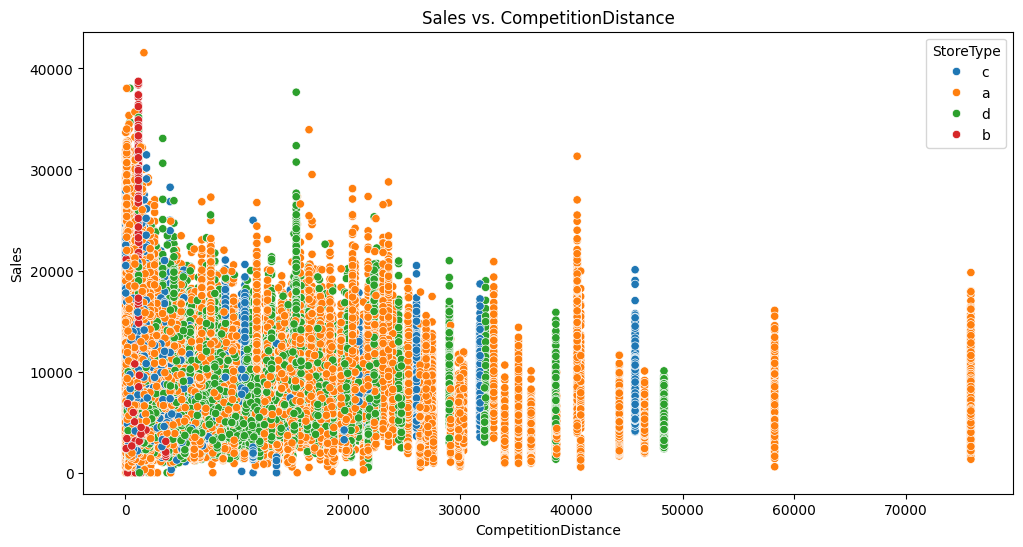

In [17]:
# Check CompetitionDistance vs Sales to see if there's any direct impact on Sales when CompetitionDistance is close to the Store

fig, ax = plt.subplots(figsize=(12,6))
sns.scatterplot(data=open_sales, x="CompetitionDistance", y="Sales", hue="StoreType")
ax.set(title="Sales vs. CompetitionDistance");

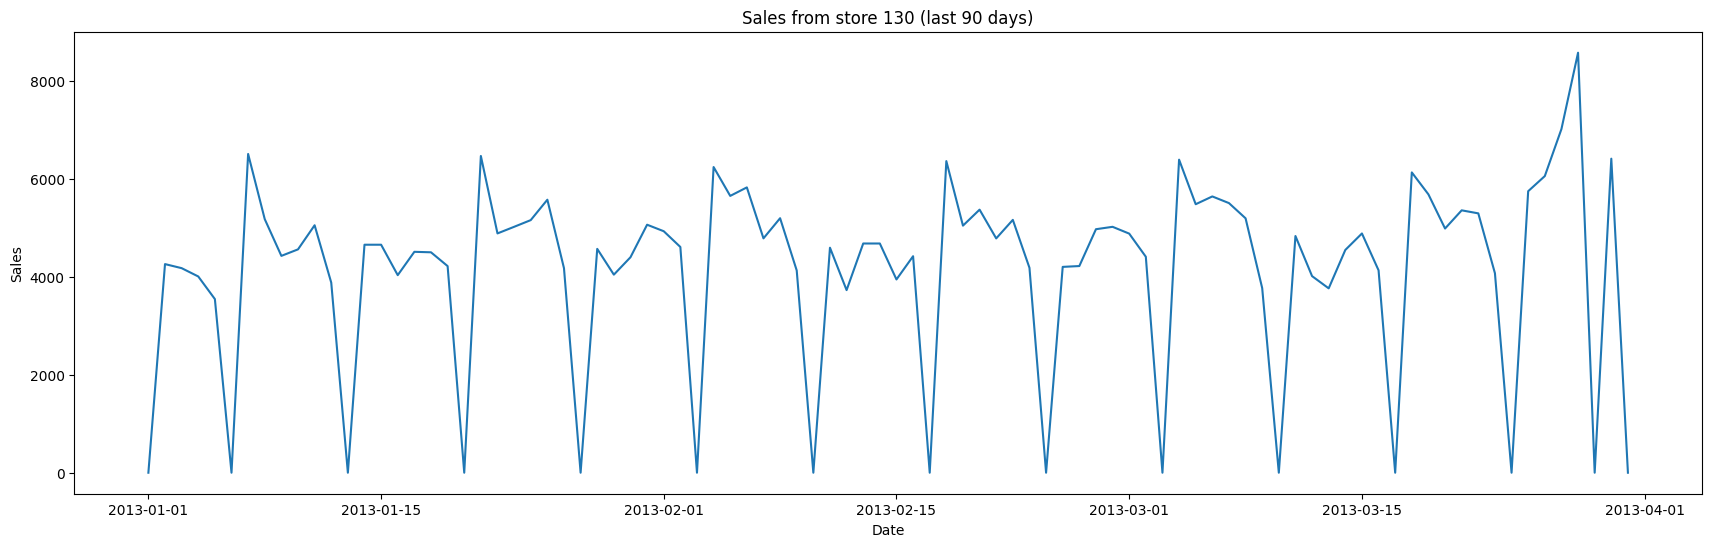

In [24]:
# Let's pick a random store and see how the sales are...
store_id = int(random.choice(open_sales["Store"].unique()))

store_data = train[train["Store"] == store_id].copy()
store_data.sort_values("Date", inplace=True)

fig, ax = plt.subplots(figsize=(21,6))
sns.lineplot(data=store_data[:90], x="Date", y="Sales")
ax.set(title=f"Sales from store {store_id} (last 90 days)");

In [62]:
# Checking found peaks in a selected store

#store_data[store_data["Sales"] > 17000]
#store_data[store_data["Date"] <= "2013-12-31"].tail(12)

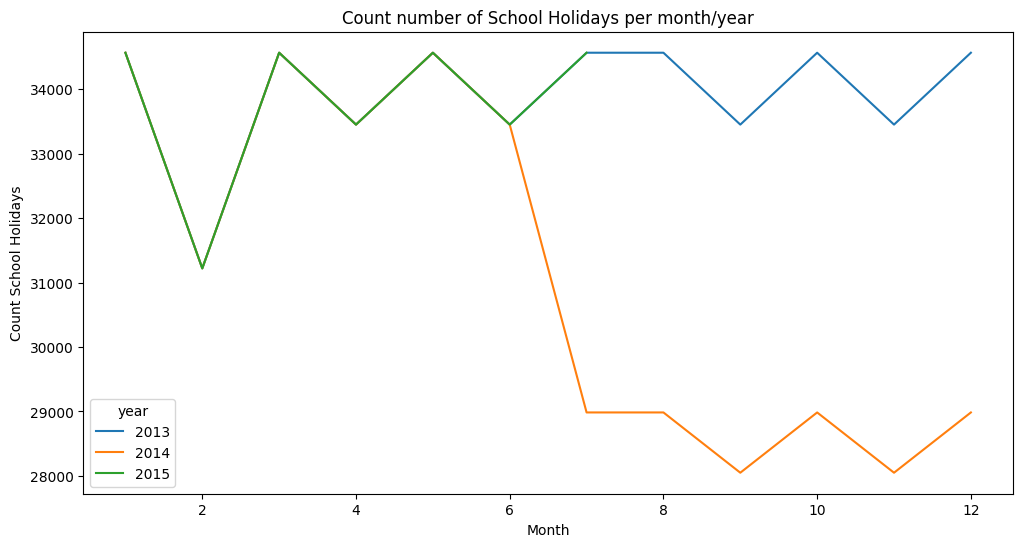

In [ ]:
# What is the number of School Holiday per month/year?
schoolholidays_year = train.groupby(
    ["year", "month"]
)["SchoolHoliday"].count().to_frame("count_SchoolHoliday")
schoolholidays_year.reset_index(inplace=True)

fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(
    data=schoolholidays_year,
    x="month",
    y="count_SchoolHoliday",
    hue="year",
    palette="tab10",
    ax=ax
)
ax.set(title="Count number of School Holidays per month/year",
        xlabel="Month", ylabel="Count School Holidays");


*EDA continues...*

**Insights**:

- Number of unique stores: **1115**
- The number of records per store varies from **758 to 942 records**.
- **Daily** granularity, **from 2013 to 2015**.
- Daily **average sales** is **6955.51** (when stores are obviusly open, *Open=1*).
- When the store is open, the **number of customers** varies from **240 to 3403**.
- *`CompetitionDistance`* vs `Sales` (by `StoreType`) did not show a clear impact in Sales. This means having a competition close to a Rossmann store did not directly impact in Sales. However, I migh find another way to check that besides plotting them in a scatter plot.
- StoreType **b** shows a higher Average Sales compared to the other store types despite it contains less records. They also contain the highest average in number of customers. This means StoreType **b** might be the larger ones.
- The number of School Holidays for 2013 and 2015 follows the same patter. However, something changed in 2014 in the 2nd semester, the number of School Holidays decreased.

___